In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches


In [5]:
import sys
sys.path.append("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project")
from scripts.tile_image import extract_tile_fixed
from sklearn.preprocessing import MinMaxScaler
with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Spot_preprocessing\\try_replace_with_rank.h5", "r") as f:
    train_spots = f["spots/Train"]
    
    # Dictionary to store DataFrames for each slide
    train_spot_tables = {}
    
    for slide_name in train_spots.keys():
        # Load dataset as NumPy structured array
        spot_array = np.array(train_spots[slide_name])
        
        # Convert to DataFrame
        df = pd.DataFrame(spot_array)
        
        # Store in dictionary
        train_spot_tables[slide_name] = df


train_L_tiles = []
train_labels = []
slides_ids = []
bad_spots = []
train_positions = []

# ======= Main Loop =======

with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try1_masked.h5", "r") as h5file:
    train_images = h5file["images/Train"]
    slide_ids = list(train_spot_tables.keys())

    for slide_id in slide_ids:
        if slide_id not in train_images:
            print(f" Slide {slide_id} not found in HDF5, skipping.")
            continue

        image = train_images[slide_id][()]  # H x W x 3
        df = train_spot_tables[slide_id]

        # Step 4: Standardized Coordinates
        ext_coords = df[['x', 'y']].values
        scaler = MinMaxScaler(feature_range=(-1, 1))
        coords_normalized = scaler.fit_transform(ext_coords)
        df[['x_normalized', 'y_normalized']] = coords_normalized

        for i, row in df.iterrows():
            x, y = int(row['x']), int(row['y'])
            nx, ny = row['x_normalized'], row['y_normalized']

            tile, padded = extract_tile_fixed(image, x, y, tile_size=78, pad_mode="edge")
            label = row.iloc[2:-2].values.astype(np.float32)
            train_positions.append(np.array([nx, ny], dtype=np.float32))
            train_L_tiles.append(tile)
            train_labels.append(label)
            slides_ids.append(slide_id)
            
            if padded is not None:
                bad_spots.append((slide_id, padded[0], padded[1]))
                
print(f"A total of {len(bad_spots)} spots experienced padding：")
for sid, x, y in bad_spots[:5]:
    print(f" - {sid}: ({x}, {y})")

A total of 0 spots experienced padding：


In [ ]:
import torch
import os
import albumentations as A
from scripts.tile_image import split_into_subtiles

save_dir = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Final_preprocessing\\train_data"
os.makedirs(save_dir, exist_ok=True)

start_counter = 0
print(f" Original data from index {start_counter} ")

for i, (l_tile, label, slide_id, position ) in enumerate(zip(train_L_tiles, train_labels, slides_ids,train_positions)):
    try:
        center_tile = l_tile  # 9 tiles
        subtiles = split_into_subtiles(center_tile)
        
        if len(subtiles) !=9 :
            print(f"{i} have wrong size {len(subtiles)}")
        data = {
            "tile": center_tile,
            "subtiles": np.stack(subtiles),
            "label": label,
            "source_idx": i,  # This can be used to track which original data entry it comes from
            "slide_idx": slide_id,  # This can be used to track which original data entry it comes from
            "position": position,
        }
        
        file_path = os.path.join(save_dir, f"tile_{start_counter + i:06d}.pt")
        torch.save(data, file_path)

    except Exception as e:
        print(f"Failed to save record {i}:{e}")
print(f" Original data has been stored in {save_dir}/original_data.pt, totaling {len(train_L_tiles)} service data")

 Original data from index 0 
✅ Original data has been stored in C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\data_preprocessing\Final_preprocessing\train_data/original_data.pt, totaling 8348 service data


 Visualizing: tile_000832.pt


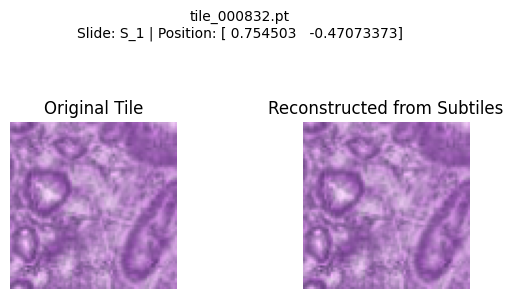

In [18]:

sys.path.append("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project")
import importlib
import scripts.valid_tile
importlib.reload(scripts.valid_tile)
from scripts.valid_tile import visualize_random_sample
visualize_random_sample(save_dir)

## Test Data Preparation ##

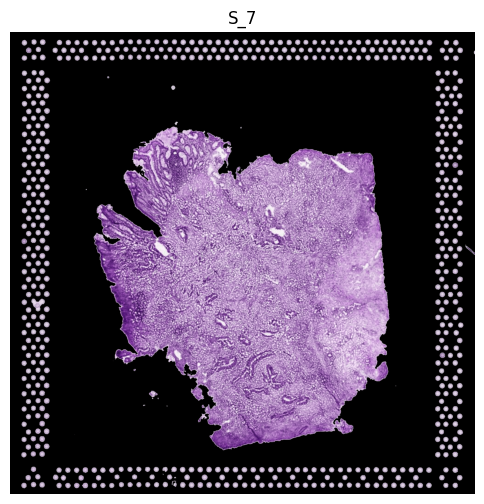

In [20]:
# Visualize Test slide ('S_7')
with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try1_masked.h5", "r") as h5file:
    test_images = h5file["images/Test"]

    sample = 'S_7'
    image = np.array(test_images[sample])
    
    plt.figure(figsize=(6,6))
    plt.imshow(image, aspect="auto")
    plt.axis('off')
    plt.title(sample)
    plt.show()

In [22]:
# Display spot table for Test slide (only the spot coordinates on 2D array)
with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5", "r") as f:
    test_spots = f["spots/Test"]
    print(test_spots.keys())
    spot_array = np.array(test_spots['S_7'])
    test_spot_table = pd.DataFrame(spot_array)
    
# Show the test spots coordinates for slide 'S_7'
test_spot_table

<KeysViewHDF5 ['S_7']>


,x,y,Test_Set
0,1499,1260,2
1,1435,1503,2
2,558,1082,2
3,736,1304,1
4,1257,1592,1
...,...,...,...
2083,736,639,2
2084,1016,684,2
2085,1181,839,2
2086,735,1436,1


In [ ]:
import h5py
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scripts.tile_image import split_into_subtiles

test_tiles = []
test_subtiles = []
bad_spots =[]
test_positions = []
source_idxs = []
with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try1_masked.h5", "r") as h5file:
    test_images = h5file["images/Test"]

    slide_ids = list(test_images.keys())  # e.g., only ['S_7']
    
    df = test_spot_table
    image = np.array(test_images['S_7'])

    ext_coords = df[['x', 'y']].values
    scaler = MinMaxScaler(feature_range=(-1, 1))
    coords_normalized = scaler.fit_transform(ext_coords)
    df[['x_normalized', 'y_normalized']] = coords_normalized
    
    for i, row in df.iterrows():
        x, y = int(row['x']), int(row['y'])
        nx, ny = row['x_normalized'], row['y_normalized']

        tile, padded = extract_tile_fixed(image, x, y, tile_size=78)

        subtiles = split_into_subtiles(tile, 3)  # 9 tiles

        
        test_positions.append(np.array([nx, ny], dtype=np.float32)) 

        test_tiles.append(tile)
        test_subtiles.append(subtiles)  
        
        source_idxs.append(i)
        if padded is not None:
            bad_spots.append((slide_id, padded[0], padded[1]))
                
print(f" A total of {len(bad_spots)} spots experienced padding：")
for sid, x, y in bad_spots[:5]:
    print(f" - {sid}: ({x}, {y})")

 A total of 0spots experienced padding：


In [24]:
import torch 
import os
output_dir = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Final_preprocessing\\test_data"
os.makedirs(output_dir,exist_ok=True)
best_model_path = os.path.join(output_dir,"test_dataset.pt")

torch.save({
    'tiles':test_tiles,
    'subtiles': test_subtiles,
    'position': test_positions,
    'source_idx': source_idxs,
},best_model_path)

print(f"Save the test dataset in !{output_dir}")

Save the test dataset in !C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\data_preprocessing\Final_preprocessing\test_data


In [26]:
import h5py
import numpy as np

# Used to accumulate statistics
train_sum = np.zeros(3, dtype=np.float64)
train_sqsum = np.zeros(3, dtype=np.float64)
train_count = 0

test_sum = np.zeros(3, dtype=np.float64)
test_sqsum = np.zeros(3, dtype=np.float64)
test_count = 0

with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try1_masked.h5", "r") as h5file:
    # Train
    train_images = h5file["images/Train"]
    for slide_id in train_images.keys():
        img = train_images[slide_id][()]  # (H,W,3)
        img = img.astype(np.float32)

        # Create a mask: all pixels with channel == 0 
        mask = ~(np.all(img == 0., axis=2))  # (H,W) True=有效

        valid_pixels = img[mask]  # shape (N,3)
        train_sum += valid_pixels.sum(axis=0)
        train_sqsum += (valid_pixels**2).sum(axis=0)
        train_count += valid_pixels.shape[0]

    # Test
    test_images = h5file["images/Test"]
    for slide_id in test_images.keys():
        img = test_images[slide_id][()]  # (H,W,3)
        img = img.astype(np.float32)

        mask = ~(np.all(img == 0., axis=2))
        valid_pixels = img[mask]
        test_sum += valid_pixels.sum(axis=0)
        test_sqsum += (valid_pixels**2).sum(axis=0)
        test_count += valid_pixels.shape[0]

# Statistical results
train_mean = train_sum / train_count
train_var = train_sqsum / train_count - train_mean**2
train_std = np.sqrt(train_var)

test_mean = test_sum / test_count
test_var = test_sqsum / test_count - test_mean**2
test_std = np.sqrt(test_var)

print("Train mean :", train_mean)
print("Train std  :", train_std)
print("Test mean  :", test_mean)
print("Test std   :", test_std)

# Merge all pixels (Train+Test)
total_sum = train_sum + test_sum
total_sqsum = train_sqsum + test_sqsum
total_count = train_count + test_count

total_mean = total_sum / total_count
total_var = total_sqsum / total_count - total_mean**2
total_std = np.sqrt(total_var)

print("All mean   :", total_mean)
print("All std    :", total_std)

Train mean : [0.6805925  0.52821957 0.74463225]
Train std  : [0.16405025 0.20129465 0.13839294]
Test mean  : [0.69920112 0.55487607 0.7586871 ]
Test std   : [0.15136251 0.18119869 0.12956747]
All mean   : [0.68377097 0.53277268 0.74703291]
All std    : [0.16210485 0.19826058 0.13702791]
